## Denetimsiz Öğrenme Nedir? (Unsupervised Learning)

Denetimsiz öğrenme, makine öğrenmesinin bir alt alanıdır ve elimizde **etiketli veri olmadan** çalışır. Yani, modelimize hangi verinin hangi kategoriye ait olduğunu söylemeyiz. Model, veriler arasındaki **örüntüleri (pattern)**, **benzerlikleri** veya **farklılıkları** kendi başına keşfetmeye çalışır.

### Temel Amaç

Denetimsiz öğrenmenin temel amacı, ham veriyi daha anlamlı gruplara ayırmak veya verinin yapısını ortaya çıkarmaktır.

### Yaygın Kullanım Alanları

- **Kümeleme (Clustering):** Benzer özellikteki verileri gruplara ayırmak (Örnek: Müşteri segmentasyonu)
- **Boyut indirgeme (Dimensionality Reduction):** Verideki gereksiz/benzer özellikleri azaltarak, daha özet ve anlamlı bir temsil oluşturmak (Örnek: Görsel veri sıkıştırma)
- **Öneri sistemleri:** Kullanıcıların ilgi alanlarını belirlemek

### Popüler Denetimsiz Öğrenme Algoritmaları

- **K-Means:** Belirli sayıda kümeye ayırır.
- **Principal Component Analysis (PCA):** Verinin boyutunu küçültür.
- **Hierarchical Clustering:** Hiyerarşik bir şekilde verileri gruplar.

### Örnek Senaryo

Bir marketteki alışveriş verileri üzerinde, müşterilerin benzer alışveriş alışkanlıklarına sahip olup olmadığını inceliyorsunuz. Hangi müşterilerin benzer grupta olduğunu önceden bilmediğiniz için denetimsiz öğrenme algoritmalarını kullanarak bu grupları otomatik olarak bulabilirsiniz.

---

Kısacası; **denetimsiz öğrenme**, veri üzerinde herhangi bir etiket olmadan, anlamlı yapılar veya gruplar keşfetmeye çalışır ve makineye "bu veri kümelerini kendi içinde ayır" deriz.

## K-Ortalamalar (K-Means) Yöntemi Nedir?

K-ortalamalar, bir veri kümesindeki benzer verileri kendi arasında gruplara (kümelere) ayıran çok popüler bir **denetimsiz öğrenme** yöntemidir.

Hiç bilmeyen biri için basitçe şöyle anlatabiliriz:

Hayal edin; elinizde karışık renkli taşlar var. Bu taşları, birbirine benzeyenler aynı grupta olacak şekilde ayırmak istiyorsunuz. Ama hangi taşın hangi gruba gireceğini baştan bilmiyorsunuz. K-ortalamalar tam olarak bunu yapar!

---

### Adım Adım K-ortalamalar Nasıl Çalışır?

1. **Kaç grup (küme) istediğimize karar veriyoruz.** (Bu sayı genellikle "K" harfiyle gösterilir. Mesela 3 grup: K=3)
2. Bilgisayar, veriler arasından rastgele K tane nokta seçer. Bunlara “merkez” denir.
3. Elimizdeki her veri noktası, hangi merkeze daha yakınsa o grubun üyesi olur.
4. Her grubun merkezi tekrar hesaplanır: Yani o gruptaki tüm verilerin ortalaması alınır ve yeni merkez bulunur.
5. Veri noktaları tekrar, en yakın yeni merkezlere atanır ve bu işlem tekrar eder.
6. Merkezler değişmemeye başlayınca (ya da yeterince değişiklik olmayınca) algoritma durur.

---

### Gerçek Hayattan Bir Örnek

- Bir market, müşterileri alışveriş alışkanlıklarına göre gruplamak istiyor.
- 3 tip müşteri olduğunu düşünüyor (K=3).
- K-ortalamalar her müşteriyi, alışveriş profilinin en çok benzediği gruba yerleştiriyor.

---

Kısacası; **K-ortalamalar yöntemi**, verideki benzer örnekleri bulup aynı grupta toplar ve bunu, hiçbir etikete ihtiyaç duymadan, tamamen otomatik olarak yapar!

In [1]:
# pip install yellowbrick

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("datasets/USArrests.csv", index_col=0)

In [3]:
df.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [4]:
df.isnull().sum()

Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 4.0+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


In [7]:
# MinMaxScaler, verideki tüm öznitelikleri 0 ile 1 arasında olacak şekilde ölçeklendirir.
# Bu işlem, değişkenlerin farklı ölçeklerde olması durumunda modelleme aşamasında avantaj sağlar.
sc = MinMaxScaler((0, 1))  # Ölçeklendirme aralığı (0,1) olarak belirleniyor.
df = sc.fit_transform(df)  # Veriye uygun olarak ölçeklendirici öğreniliyor ve veri dönüştürülüyor.
df[0:5]  # Ölçeklendirilmiş verinin ilk 5 satırını gösterir.

array([[0.74698795, 0.65410959, 0.44067797, 0.35917313],
       [0.55421687, 0.74657534, 0.27118644, 0.96124031],
       [0.43975904, 0.85273973, 0.81355932, 0.6124031 ],
       [0.48192771, 0.49657534, 0.30508475, 0.31524548],
       [0.4939759 , 0.79109589, 1.        , 0.86046512]])

In [8]:
# KMeans algoritması, veriyi kümelemek için kullanılan popüler bir denetimsiz öğrenme yöntemidir. 
# Burada, n_clusters=4 seçilerek yani verinin 4 kümeye ayrılması isteniyor. 
# random_state=17 argümanı ise kümeleme işleminin her çalıştırmada aynı sonucu verebilmesi için rastgelelik kontrolü sağlıyor.
# fit(df) ile model veriye uygulanıyor ve kümeler öğreniliyor.
kmeans = KMeans(n_clusters=4, random_state=17).fit(df)

# kmeans.get_params() fonksiyonu ise oluşturulan KMeans nesnesinin parametrelerini gösterir.
kmeans.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 4,
 'n_init': 'auto',
 'random_state': 17,
 'tol': 0.0001,
 'verbose': 0}

In [10]:
# kmeans.n_clusters: Model oluşturulurken belirlenen küme sayısını gösterir. 
# Bu örnekte n_clusters=4 olarak ayarlandığı için, bu özellik 4 döndürür.
print("Küme sayısı (n_clusters):", kmeans.n_clusters)

# kmeans.cluster_centers_: Her kümenin merkezini (merkez noktalarını) gösterir. 
# Her satır bir kümenin merkezi, her sütun ise öznitelikleri ifade eder. 
print("\nKüme merkezleri (cluster_centers_):\n", kmeans.cluster_centers_)

# kmeans.labels_: Her gözlemin (satırın), hangi kümeye ait olduğunu gösterir. 
# Her gözlem için bir küme etiketi (0, 1, 2, 3 gibi) içerir.
print("\nHer gözlemin ait olduğu küme (labels_):\n", kmeans.labels_)

# kmeans.inertia_: Kümeleme sonucunda gözlemler ile merkezler arasındaki toplam karesel mesafeyi gösterir.
# Daha düşük inertia, kümelerin gözlemlerle daha iyi eşleştiği anlamına gelir.
print("\nToplam karesel hata (inertia_):", kmeans.inertia_)

Küme sayısı (n_clusters): 4

Küme merkezleri (cluster_centers_):
 [[0.1686747  0.11485774 0.34028683 0.12601868]
 [0.6124498  0.75       0.75423729 0.67980189]
 [0.30439405 0.32937147 0.70588235 0.31098951]
 [0.79141566 0.6802226  0.36864407 0.36466408]]

Her gözlemin ait olduğu küme (labels_):
 [3 1 1 3 1 1 2 2 1 3 2 0 1 2 0 2 0 3 0 1 2 1 0 3 2 0 0 1 0 2 1 1 3 0 2 2 2
 2 2 3 0 3 1 2 0 2 2 0 0 2]

Toplam karesel hata (inertia_): 3.6834561535859134


### Optimum Küme Sayısı

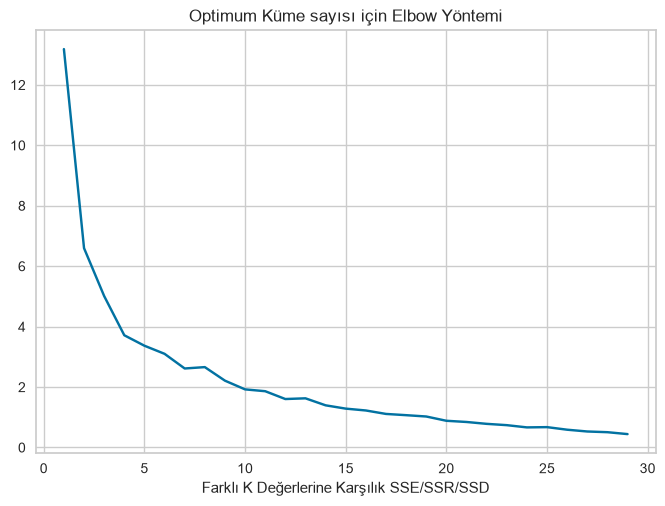

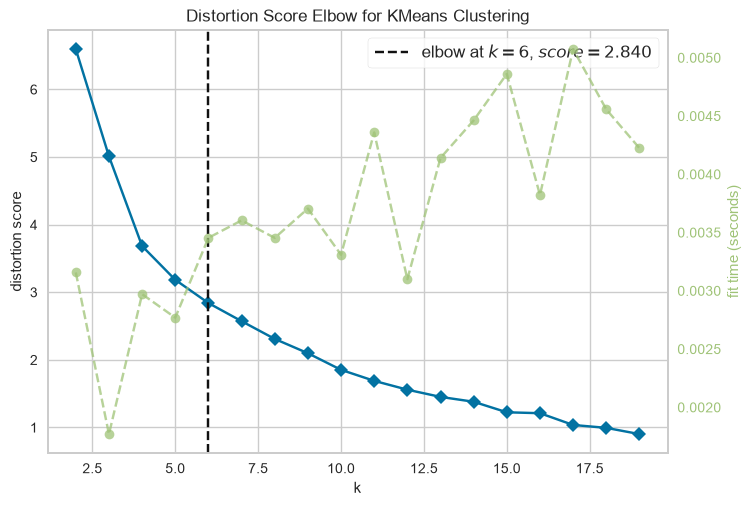

np.int64(6)

In [ ]:
# Elbow Yöntemi ile optimum küme sayısını bulmak

# inertia değerlerini saklamak için boş bir liste oluşturulur
ssd = []

# 1'den 29'a kadar her küme sayısı denenir
K = range(1, 30)

for k in K:
    # k küme için KMeans modeli oluştur
    kmeans = KMeans(n_clusters=k)
    # Modeli veriye uygula
    kmeans.fit(df)
    # O kümeleme sonucu toplam karesel hata değerini (inertia) kaydet
    ssd.append(kmeans.inertia_)

# Küme sayısına karşılık inertia değerlerini çiz
plt.plot(K, ssd, "bx-")
plt.xlabel("Küme Sayısı (K)")
plt.ylabel("Toplam Hata (Inertia / SSD)")
plt.title("Elbow (Dirsek) Yöntemi ile Küme Sayısı Seçimi")
plt.show()

# Dirseğin kırıldığı noktayı görsel olarak belirleyebiliriz

# Şimdi otomatik olarak optimum küme sayısını bulalım
from yellowbrick.cluster import KElbowVisualizer

# KMeans modelini oluştur
kmeans = KMeans(n_init=10, random_state=17)

# KElbowVisualizer ile 2 ila 20 arasında dene
elbow = KElbowVisualizer(kmeans, k=(2, 20), force_model=True)
# Modeli veriye uygula ve grafiği çizdir
elbow.fit(df)
elbow.show()

# Otomatik olarak bulunan en uygun küme sayısı:
elbow.elbow_value_

### Final Cluster'ların Oluşturulması


In [15]:
# 1. KMeans modelini optimum küme sayısı ile oluştur ve veriye uygula
kmeans = KMeans(n_clusters=elbow.elbow_value_, random_state=17)
kmeans.fit(df)

# 2. Kümelerin merkezlerini ve etiketlerini incele
print("Küme sayısı:", kmeans.n_clusters)
print("Küme merkezleri:\n", kmeans.cluster_centers_)
print("Her gözlemin ait olduğu küme:", kmeans.labels_)

# 3. Her gözlemin hangi kümeye ait olduğunu bir değişkende tut
clusters_kmeans = kmeans.labels_

# 4. Orijinal veriyi tekrar oku (küme atamalarını eklemek için)
df = pd.read_csv("datasets/USArrests.csv", index_col=0)


Küme sayısı: 6
Küme merkezleri:
 [[  2.95        62.7         53.9         11.51         1.2       ]
 [ 11.82222222 250.55555556  68.          28.           3.22222222]
 [  6.11111111 159.11111111  73.55555556  20.37777778   3.22222222]
 [  5.59       112.4         65.6         17.27         3.        ]
 [ 11.8        300.85714286  68.71428571  28.85714286   3.14285714]
 [ 12.         198.8         65.4         27.28         3.6       ]]
Her gözlemin ait olduğu küme: [1 1 4 5 4 5 3 1 4 5 0 3 1 3 0 3 3 1 0 4 2 1 0 1 2 3 3 1 0 2 4 1 4 0 3 2 2
 3 2 4 0 5 5 3 0 2 2 0 0 2]


In [16]:
# 5. Küme etiketlerini veriye yeni bir sütun olarak ekle
df["cluster"] = clusters_kmeans

# 6. Sonuç tablosunun ilk birkaç satırını görüntüle
print(df.head())

            Murder  Assault  UrbanPop  Rape  cluster
Alabama       13.2      236        58  21.2        1
Alaska        10.0      263        48  44.5        1
Arizona        8.1      294        80  31.0        4
Arkansas       8.8      190        50  19.5        5
California     9.0      276        91  40.6        4


In [17]:
# 7. (Opsiyonel) Küme indexlemesini 1'den başlatmak için küme numarasını 1 artır
df["cluster"] = df["cluster"] + 1

# 8. 5 numaralı kümeye ait şehirleri görüntüle (örnek)
print(df[df["cluster"] == 5])

                Murder  Assault  UrbanPop  Rape  cluster
Arizona            8.1      294        80  31.0        5
California         9.0      276        91  40.6        5
Florida           15.4      335        80  31.9        5
Maryland          11.3      300        67  27.8        5
New Mexico        11.4      285        70  32.1        5
North Carolina    13.0      337        45  16.1        5
South Carolina    14.4      279        48  22.5        5


In [18]:
# 9. Her küme için count, mean ve median değerlerini gruplayarak incele
print(df.groupby("cluster").agg(["count", "mean", "median"]))

# 10. Sonuçları bir csv dosyasına kaydet
df.to_csv("clusters.csv")

        Murder                   Assault                    UrbanPop  \
         count       mean median   count        mean median    count   
cluster                                                                
1           10   2.950000    2.4      10   62.700000   56.5       10   
2            9  11.822222   12.1       9  250.555556  252.0        9   
3            9   6.111111    6.6       9  159.111111  159.0        9   
4           10   5.590000    6.0      10  112.400000  111.5       10   
5            7  11.800000   11.4       7  300.857143  294.0        7   
6            5  12.000000   12.7       5  198.800000  201.0        5   

                           Rape                    
              mean median count       mean median  
cluster                                            
1        53.900000   53.5    10  11.510000  11.00  
2        68.000000   72.0     9  28.000000  24.00  
3        73.555556   70.0     9  20.377778  20.00  
4        65.600000   65.5    10  17.270

### Hiyerarşik Kümeleme Analizi

Orijinal veri setinden ilk 5 satır:
             Murder  Assault  UrbanPop  Rape
Alabama       13.2      236        58  21.2
Alaska        10.0      263        48  44.5
Arizona        8.1      294        80  31.0
Arkansas       8.8      190        50  19.5
California     9.0      276        91  40.6
Ölçeklendirilmiş ilk 5 gözlem:
 [[0.74698795 0.65410959 0.44067797 0.35917313]
 [0.55421687 0.74657534 0.27118644 0.96124031]
 [0.43975904 0.85273973 0.81355932 0.6124031 ]
 [0.48192771 0.49657534 0.30508475 0.31524548]
 [0.4939759  0.79109589 1.         0.86046512]]
Linkage çıktısından ilk 5 satır:
 [[14.         28.          0.04998623  2.        ]
 [12.         31.          0.08718602  2.        ]
 [13.         15.          0.10756005  2.        ]
 [22.         48.          0.1244755   2.        ]
 [19.         30.          0.13268872  2.        ]]


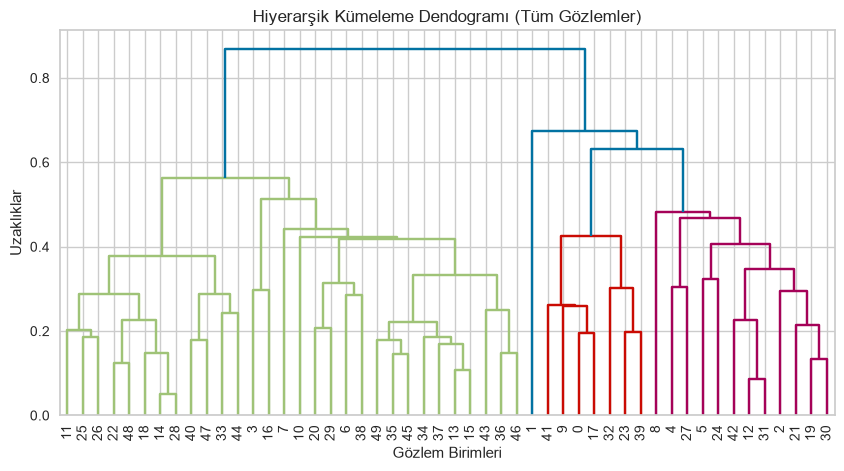

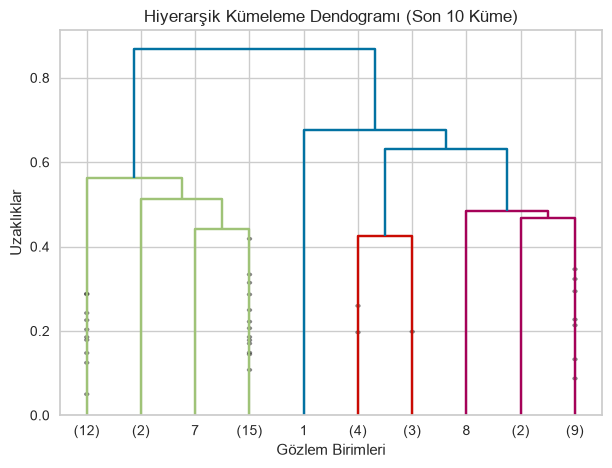

In [20]:
# 1. Adım: Veriyi oku
df = pd.read_csv("datasets/USArrests.csv", index_col=0)
print("Orijinal veri setinden ilk 5 satır:\n", df.head())

# 2. Adım: Veriyi ölçeklendir (MinMaxScaler ile 0-1 arasına getir)
sc = MinMaxScaler((0, 1))
df_scaled = sc.fit_transform(df)
print("Ölçeklendirilmiş ilk 5 gözlem:\n", df_scaled[:5])

# 3. Adım: 'average' bağlantı (linkage) yöntemi ile hiyerarşik kümeleme yap
hc_average = linkage(df_scaled, "average")
print("Linkage çıktısından ilk 5 satır:\n", hc_average[:5])

# 4. Adım: Tam dendogramı çizdir
plt.figure(figsize=(10, 5))
plt.title("Hiyerarşik Kümeleme Dendogramı (Tüm Gözlemler)")
plt.xlabel("Gözlem Birimleri")
plt.ylabel("Uzaklıklar")
dendrogram(hc_average, leaf_font_size=10)
plt.show()

# 5. Adım: Dendogramın son 10 birleşimini görüntüle
# Burada truncate_mode='lastp' parametresi, sadece en son p kadar kümeyi (birleşimi) gösterir.
# Yani, dendogramda detaylar gizlenir ve son birleşmeler vurgulanır.
# p parametresi, en altta gösterilecek grup/birleşim sayısını belirler.
# show_contracted=True kullanırsak, gizlenen alt dallar küçük üçgenler ile gösterilir,
# böylece hangi alt kümelerin birleştirildiğini kısaca görebiliriz.
plt.figure(figsize=(7, 5))
plt.title("Hiyerarşik Kümeleme Dendogramı (Son 10 Küme)")
plt.xlabel("Gözlem Birimleri")
plt.ylabel("Uzaklıklar")
dendrogram(
    hc_average,
    truncate_mode="lastp",    # sadece son p birleşimini göster
    p=10,                     # gösterilecek grup/birleşim adeti
    show_contracted=True,     # gizli kalan birleşimleri üçgenle göster
    leaf_font_size=10
)
plt.show()

### Küme Sayısını Belirlemek

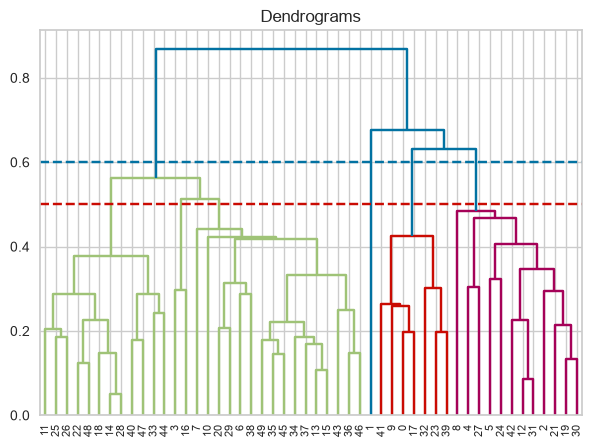

In [ ]:
# Dendrogram üzerinde, kümelerin hangi uzaklıkta birleştiğini ve uygun küme sayısının nasıl seçilebileceğini göstermek için aşağıdaki kod kullanılır.
plt.figure(figsize=(7, 5))
plt.title("Dendrogram: Uygun Küme Sayısını Seçme")
# Bütün birleşimleri çiziyoruz
dend = dendrogram(hc_average)
# Kırmızı çizgi, kümeleri ayırmak için kullanılabilecek bir eşik örneğidir (y=0.5'te).
plt.axhline(y=0.5, color='r', linestyle='--', label="Eşik: 0.5")
# Mavi çizgi ise farklı bir eşik değerini gösterir (y=0.6'da).
plt.axhline(y=0.6, color='b', linestyle='--', label="Eşik: 0.6")
plt.xlabel("Gözlem Birimleri (Birleşme Sırası)")
plt.ylabel("Kümeler Arası Uzaklık")
plt.legend()
plt.show()

# Açıklama:
# Dendrogramda yatay eksen, gözlem birimlerinin veya gruplarının hangi sırayla birleştiğini;
# dikey eksen ise kümeler arasındaki uzaklığı gösterir.
# Genellikle, büyük bir "mesafe sıçraması" olan yerden bir yatay çizgi çekilerek 
# uygun küme sayısı seçilir. Kırmızı ve mavi kesikli çizgiler, olası eşik örnekleridir.
# Bu çizgilerin kesiştiği noktalardaki dal (branch) sayısı, önerilen küme adedini verir.

### Final Modeli Oluşturma

In [23]:
# 1. Gerekli kütüphaneyi yüklüyoruz
from sklearn.cluster import AgglomerativeClustering

# 2. AgglomerativeClustering modelini oluşturuyoruz ve kaç küme olacağını belirtiyoruz.
cluster = AgglomerativeClustering(n_clusters=5, linkage="average")

# 3. Veriye göre kümeleri tahmin ediyoruz
clusters = cluster.fit_predict(df)  # clusters: gözlem başına 0'dan başlayan küme etiketi

# 4. Orijinal veriyi tekrar yüklüyoruz (saf haliyle).
df = pd.read_csv("datasets/USArrests.csv", index_col=0)

# 5. Hiyerarşik kümeleme sonucu elde edilen kümeleri yeni bir sütun olarak ekliyoruz.
df["hi_cluster_no"] = clusters + 1  # 1'den başlatmak için 1 ekliyoruz

# 6. KMeans ile oluşturulan cluster etiketlerini de ekliyoruz (kmeans_cluster_no'yu doğrudan oluştur)
# Bu adımda clusters_kmeans değişkeninin daha önce tanımlı/kullanıma hazır olduğu varsayılıyor.
df["kmeans_cluster_no"] = clusters_kmeans + 1  # 1'den başlatmak için 1 ekliyoruz

### Temel Bileşen Analizi (PCA - Principal Component Analysis) Nedir?

**Temel Bileşen Analizi (PCA)**, çok değişkenli verilerde boyut indirgeme amacıyla kullanılan istatistiksel bir tekniktir. PCA, bir veri setindeki değişkenler arasındaki korelasyonu kullanarak, orijinal boyutlardan daha az sayıda yeni ve bağımsız (birbirinden korelasyonsuz) değişken (bileşen) elde etmeyi amaçlar.

#### PCA'nın Temel Amaçları:
- **Boyut indirgeme:** Çok sayıda değişkenin yerini, bilgi kaybını en aza indirerek daha az sayıda temel bileşenle temsil etmek.
- **Veri Görselleştirme:** Özellikle yüksek boyutlu verileri 2 veya 3 bileşenle görselleştirmek.
- **Çoklu doğrusal bağlantının etkisini azaltmak** ve **modellemeyi kolaylaştırmak**.

#### PCA Nasıl Çalışır?
1. Veriler standartlaştırılır (özelliklerin ortalaması alınır ve standart sapmasına bölünür).
2. Kovaryans matrisi oluşturulur.
3. Kovaryans matrisinin özdeğerleri ve özvektörleri hesaplanır.
4. En yüksek özdeğere sahip bileşenler seçilir; bu bileşenler, verideki değişkenliğin büyük bölümünü açıklar.
5. Orijinal veri seçilen bileşenlere projekte edilerek boyut indirgeme sağlanır.

#### PCA'nın Sağladığı Faydalar
- Yüksek boyutlu veri setlerinde hesaplama karmaşıklığını azaltır.
- Gürültüyü azaltır, sınıflandırma veya regresyon performansını artırabilir.
- Değişkenler arası korelasyonları ortadan kaldırıp, daha yalın bir veri seti sunar.

#### Özetle:
Temel Bileşen Analizi, verilerin temel yapısını koruyarak, değişken sayısını azaltmak için kullanılan güçlü bir araçtır. Özellikle görselleştirme, gürültü azaltma ve daha etkili modelleme için sıkça tercih edilir.

In [24]:
df = pd.read_csv("datasets/Hitters.csv")
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [36]:
num_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col]) and "Salary" not in col]

df[num_cols].head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4


In [37]:
df = df[num_cols]

In [38]:
df.dropna(inplace=True)

In [39]:
df.shape

(322, 16)

In [40]:
df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns)

In [41]:
# PCA nesnesi oluşturuluyor
pca = PCA()

# PCA modeli veriye uygulanıyor ve verinin ana bileşenlere indirgenmiş hali elde ediliyor
pca_fit = pca.fit_transform(df)

# Her bir ana bileşenin verideki toplam varyanstan ne kadarını açıkladığını gösterir
print("Bileşenlerin açıkladığı varyans oranları:", pca.explained_variance_ratio_)

# Bileşenlerin kümülatif olarak açıkladığı toplam varyans yüzdelerini gösterir
print("Kümülatif açıklanan varyans oranları:", np.cumsum(pca.explained_variance_ratio_))

Bileşenlerin açıkladığı varyans oranları: [4.60378552e-01 2.60398491e-01 1.03388605e-01 5.36902121e-02
 4.20784091e-02 2.96359092e-02 1.57079101e-02 1.13928108e-02
 7.83230398e-03 5.87669497e-03 3.74765194e-03 3.09384056e-03
 1.55679403e-03 8.59034766e-04 2.86873704e-04 7.59064046e-05]
Kümülatif açıklanan varyans oranları: [0.46037855 0.72077704 0.82416565 0.87785586 0.91993427 0.94957018
 0.96527809 0.9766709  0.9845032  0.9903799  0.99412755 0.99722139
 0.99877819 0.99963722 0.99992409 1.        ]


### Optimum Bileşen Sayısı

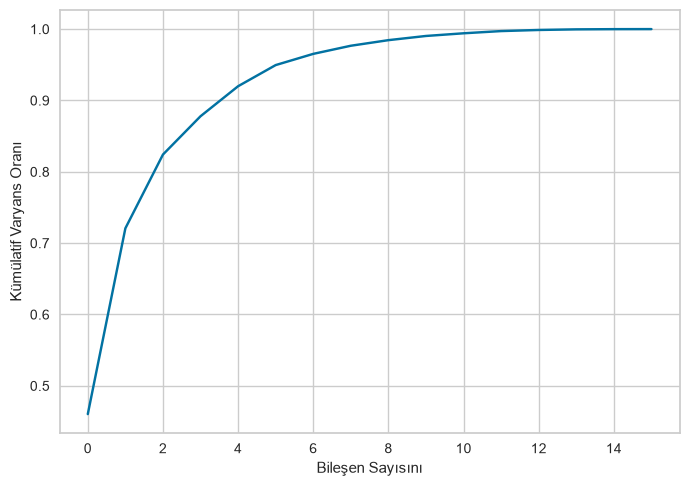

In [42]:
pca = PCA().fit(df)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Bileşen Sayısını")
plt.ylabel("Kümülatif Varyans Oranı")
plt.show()

### Final PCA'in Oluşturulması


In [43]:
# PCA nesnesi 3 bileşenli olarak oluşturuluyor
pca = PCA(n_components=3)

# Verilere PCA uygulanıyor ve ilk 3 ana bileşene indirgenmiş hali elde ediliyor
pca_fit = pca.fit_transform(df)

# Her bir ana bileşenin açıkladığı varyans oranı ekrana yazdırılıyor
print("İlk 3 ana bileşenin açıkladığı varyans oranları:", pca.explained_variance_ratio_)

# Bileşenlerin kümülatif olarak açıkladığı toplam varyans yüzdesi ekrana yazdırılıyor
print("Kümülatif açıklanan varyans oranları:", np.cumsum(pca.explained_variance_ratio_))

İlk 3 ana bileşenin açıkladığı varyans oranları: [0.46037855 0.26039849 0.1033886 ]
Kümülatif açıklanan varyans oranları: [0.46037855 0.72077704 0.82416565]


### BONUS: Principal Component Regression


In [44]:
df = pd.read_csv("datasets/Hitters.csv")
df.shape

(322, 20)

In [45]:
len(pca_fit)

322

In [46]:
num_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col]) and "Salary" not in col]
len(num_cols)

16

In [47]:
others = [col for col in df.columns if col not in num_cols]

pd.DataFrame(pca_fit, columns=["PC1","PC2","PC3"]).head()

,PC1,PC2,PC3
0,-3.240106,0.253173,0.776066
1,0.245488,-1.302951,0.118040
2,0.603883,2.617002,-0.698183
3,3.591276,-0.547821,-1.049022
4,-2.264528,0.698898,-1.290536


In [48]:
df[others].head()


,League,Division,Salary,NewLeague
0,A,E,NaN,A
1,N,W,475.0,N
2,A,W,480.0,A
3,N,E,500.0,N
4,N,E,91.5,N


In [49]:
final_df = pd.concat([pd.DataFrame(pca_fit, columns=["PC1","PC2","PC3"]),
                      df[others]], axis=1)
final_df.head()

,PC1,PC2,PC3,League,Division,Salary,NewLeague
0,-3.240106,0.253173,0.776066,A,E,NaN,A
1,0.245488,-1.302951,0.118040,N,W,475.0,N
2,0.603883,2.617002,-0.698183,A,W,480.0,A
3,3.591276,-0.547821,-1.049022,N,E,500.0,N
4,-2.264528,0.698898,-1.290536,N,E,91.5,N


In [50]:
# Burada, Principal Component Regression (PCR) yapabilmek için bazı ön işlemler gerçekleştiriliyor.

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Kategorik (binary) olan değişkenleri makine öğrenmesi modellerinin anlayabileceği şekilde 0 ve 1'e çeviriyoruz.
# Bunun için bir etiketleyici (LabelEncoder) fonksiyonu yazdık.
def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

# Hitters veri setinde kategorik olan "NewLeague", "Division", "League" değişkenlerini encode ediyoruz.
for col in ["NewLeague", "Division", "League"]:
    label_encoder(final_df, col)

# Modelleme öncesinde eksik değer içeren satırları siliyoruz ki model eğitiminde sorun olmasın.
final_df.dropna(inplace=True)

In [51]:
y = final_df["Salary"]
X = final_df.drop(["Salary"], axis=1)

lm = LinearRegression()
rmse = np.mean(np.sqrt(-cross_val_score(lm, X, y, cv=5, scoring="neg_mean_squared_error")))
y.mean()

np.float64(535.9258821292775)

In [52]:
cart = DecisionTreeRegressor()
rmse = np.mean(np.sqrt(-cross_val_score(cart, X, y, cv=5, scoring="neg_mean_squared_error")))

cart_params = {'max_depth': range(1, 11),
               "min_samples_split": range(2, 20)}

In [53]:
cart_best_grid = GridSearchCV(cart,
                              cart_params,
                              cv=5,
                              n_jobs=-1,
                              verbose=True).fit(X, y)

cart_final = DecisionTreeRegressor(**cart_best_grid.best_params_, random_state=17).fit(X, y)

rmse = np.mean(np.sqrt(-cross_val_score(cart_final, X, y, cv=5, scoring="neg_mean_squared_error")))


Fitting 5 folds for each of 180 candidates, totalling 900 fits


#### BONUS: PCA ile Çok Boyutlu Veriyi 2 Boyutta Görselleştirme

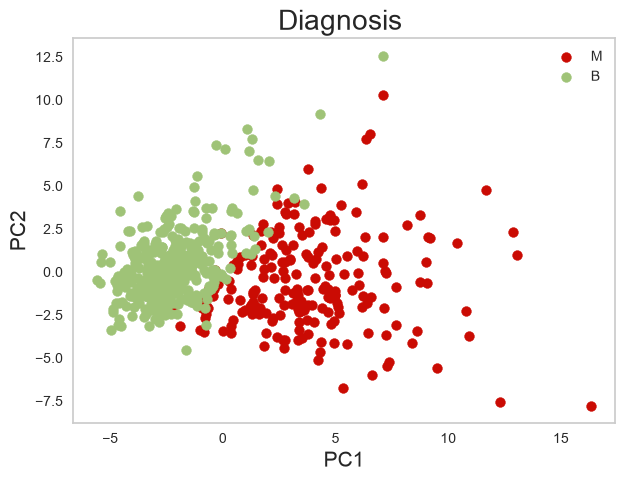

In [54]:
################################
# Breast Cancer - PCA ile Görselleştirme Açıklaması
################################

# pandas'ın çıktı ayarlarını genişletiyoruz ki veri setini rahatça inceleyebilelim.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

# Veri setini yüklüyoruz. Bu veri setinde meme kanseri teşhis verileri var.
df = pd.read_csv("datasets/breast_cancer.csv")

# "diagnosis" sütunu hedef değişken (yani sınıf, hasta mı değil mi?), geri kalanlar ise özellikler.
y = df["diagnosis"]
X = df.drop(["diagnosis", "id"], axis=1)  # ID anlamsız bir sütun olduğu için modelden çıkarılır.

# PCA uygulaması ve sonrasında yeni dataframe oluşturmak için fonksiyon:
def create_pca_df(X, y):
    # Özellikleri standartlaştırıyoruz, çünkü PCA ölçekten etkilenir.
    X = StandardScaler().fit_transform(X)
    # 2 ana bileşene indirgeme yapıyoruz (görselde kolay görüntülemek için)
    pca = PCA(n_components=2)
    pca_fit = pca.fit_transform(X)
    # Ana bileşenlerden yeni bir DataFrame oluşturuyoruz.
    pca_df = pd.DataFrame(data=pca_fit, columns=['PC1', 'PC2'])
    # Etiket (diagnosis) ile ana bileşenleri birleştiriyoruz, sınıfları görebilmek için.
    final_df = pd.concat([pca_df, pd.DataFrame(y)], axis=1)
    return final_df

# Fonksiyon ile PCA DataFrame'ini oluşturuyoruz.
pca_df = create_pca_df(X, y)

# PCA çıktısını iki boyutta grafiğe döken fonksiyon:
def plot_pca(dataframe, target):
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(1, 1, 1)
    ax.set_xlabel('PC1', fontsize=15)
    ax.set_ylabel('PC2', fontsize=15)
    ax.set_title(f'{target.capitalize()} ', fontsize=20)

    # Sınıfların her biri için farklı renk seçiyoruz, ki ayrımı grafik üzerinden görebilelim.
    targets = list(dataframe[target].unique())
    colors = random.sample(['r', 'b', "g", "y"], len(targets))

    for t, color in zip(targets, colors):
        indices = dataframe[target] == t
        ax.scatter(dataframe.loc[indices, 'PC1'],
                   dataframe.loc[indices, 'PC2'],
                   c=color, s=50)
    ax.legend(targets)
    ax.grid()
    plt.show()

# Son olarak görselleştirme fonksiyonunu çağırıyoruz.
plot_pca(pca_df, "diagnosis")


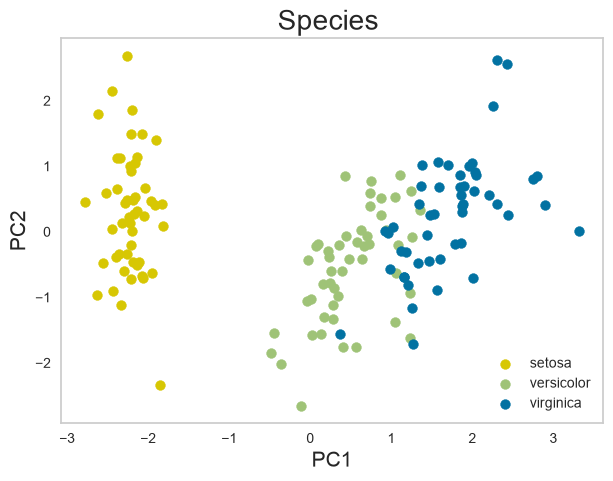

In [55]:
# Iris

import seaborn as sns
df = sns.load_dataset("iris")

y = df["species"]
X = df.drop(["species"], axis=1)

pca_df = create_pca_df(X, y)

plot_pca(pca_df, "species")

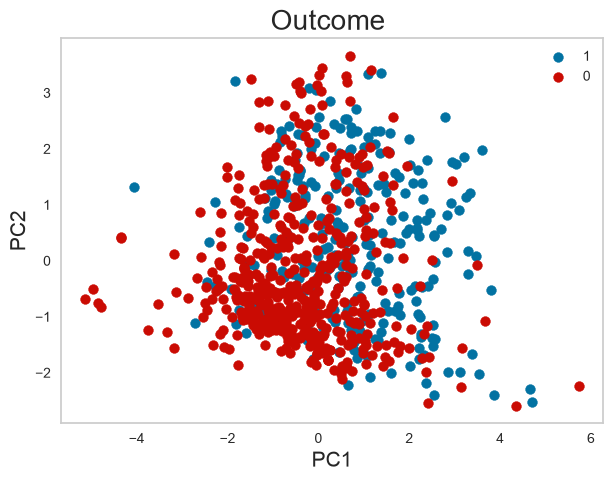

In [56]:
# Diabetes

df = pd.read_csv("datasets/diabetes.csv")

y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)

pca_df = create_pca_df(X, y)

plot_pca(pca_df, "Outcome")
